# Data Loading

In [1]:
import pandas as pd
import numpy as np
import os
import torch
from pathlib import Path
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
from transformers import AutoProcessor, CLIPModel
from tqdm import tqdm

/Users/yongchenhow/Local Data/Nus/Class/Intelligent Reasoning System/Practice Module/Project/fashion-recommender/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the article metadata
current_folder = Path.cwd()
project_root = current_folder.parent.parent.parent
DATA_DIR = project_root / "data" / "raw"
ARTICLES_PATH = os.path.join(DATA_DIR, "articles.csv")
CUSTOMERS_PATH = os.path.join(DATA_DIR, "customers.csv")
TRANSACTIONS_PATH = os.path.join(DATA_DIR, "transactions_train.csv")

# Ensure IDs are strings for safe joins
articles_df = pd.read_csv(ARTICLES_PATH, dtype={"article_id": "string"})
customers = pd.read_csv(CUSTOMERS_PATH, dtype={"customer_id": "string"})
transactions = pd.read_csv(
    TRANSACTIONS_PATH,
    dtype={"customer_id": "string", "article_id": "string"},
    parse_dates=["t_dat"],
)

print("articles:", articles_df.shape)
print("customers:", customers.shape)
print("transactions:", transactions.shape)


articles: (105542, 25)
customers: (1371980, 7)
transactions: (31788324, 5)


# Data Cleaning

In [3]:
# Create Check Function
def check_image_exists(article_id):
    # Get the first 3 digit for the subfolder
    subfolder = article_id[:3]

    # Construct the image path
    image_path = os.path.join(DATA_DIR, "images", subfolder, f"{article_id}.jpg")

    return os.path.exists(image_path)

# Scan and Filter
print(f"Original articles count: {len(articles_df)}")
print("Scanning for images...")

# Check if images exist and filter the articles
articles_df["has_image"] = articles_df["article_id"].apply(check_image_exists)

# Filter articles that have images
clean_articles_df = articles_df[articles_df["has_image"]].copy()

# Drop the helper column
clean_articles_df.drop(columns=["has_image"], inplace=True)

print(f"Articles with images: {len(clean_articles_df)}")
print(f"Dropped articles without images: {len(articles_df) - len(clean_articles_df)}")

Original articles count: 105542
Scanning for images...
Articles with images: 105100
Dropped articles without images: 442


# Top-Bottom Filtering

In [4]:
# Ensure IDs are properly formatted strings
clean_articles_df["article_id"] = clean_articles_df["article_id"].apply(lambda x: f"{int(x):010d}")

# Determine Gender
is_ladies_index = clean_articles_df['index_name'].isin(['Ladieswear', 'Divided'])
is_mens_index = clean_articles_df['index_name'] == 'Menswear'
clean_articles_df['broad_gender'] = np.select([is_ladies_index, is_mens_index], ['Ladieswear', 'Menswear'], default='other')

# Determine Type ('top' vs 'bottom')
is_top = clean_articles_df['product_group_name'] == 'Garment Upper body'
is_bottom = clean_articles_df['product_group_name'] == 'Garment Lower body'
clean_articles_df['broad_type'] = np.select([is_top, is_bottom], ['Top', 'Bottom'], default='other')

# CREATE THE COMBINED CATEGORY
clean_articles_df['combined_category'] = clean_articles_df['broad_gender'] + ' ' + clean_articles_df['broad_type']

# 5. Filter and Format
master_clean_df = clean_articles_df[
    (clean_articles_df['broad_gender'] != 'other') & 
    (clean_articles_df['broad_type'] != 'other')
].copy()


In [5]:
# AI VISUAL CLEANING ---

# 1. Setup OpenAI Base CLIP
# This will automatically use your Mac's 'mps' (Metal Performance Shaders) for faster processing
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
model_id = "openai/clip-vit-base-patch32"

print(f"Loading AI Gatekeeper ({model_id}) on {device}...")
model = CLIPModel.from_pretrained(model_id).to(device)
processor = AutoProcessor.from_pretrained(model_id)

vton_qc_prompts = [
    "a full studio shot of a single, flat-laid piece of clothing, showing the entire complete silhouette",
    "a cropped image, folded clothes, stacked items, multipacks, or an extreme close-up detail shot where the edges of the garment are cut off"
]

valid_vton_ids = []
dropped_macro_count = 0

print(f"\nScanning {len(master_clean_df)} images for close-ups...")

# 2. The AI Scan Loop
for index, row in tqdm(master_clean_df.iterrows(), total=len(master_clean_df)):
    # Ensure ID is a 10-digit string
    article_id = str(row['article_id']).zfill(10)
    subfolder = article_id[:3]
    img_path = os.path.join(DATA_DIR, "images", subfolder, f"{article_id}.jpg")
    
    try:
        # Load and process the image
        image = Image.open(img_path).convert("RGB")
        qc_inputs = processor(text=vton_qc_prompts, images=image, return_tensors="pt", padding=True).to(device)
        
        with torch.no_grad():
            # Get the probabilities
            qc_probs = model(**qc_inputs).logits_per_image.softmax(dim=1)[0].cpu().numpy()
            
        # 3. The Decision Logic
        # Index 0 is "Full shot". Index 1 is "Close-up".
        if qc_probs[0] > qc_probs[1]:
            # It's a full item! Save the ID.
            valid_vton_ids.append(article_id)
        else:
            # It's a close-up. Drop it.
            dropped_macro_count += 1
            
    except Exception as e:
        print(f"Corrupted image skipped: {article_id}")
        continue

# 4. Filter the original dataframe using the surviving IDs
vton_ready_df = master_clean_df[master_clean_df['article_id'].isin(valid_vton_ids)].copy()

print("\n--- PHASE 2 CLEANING COMPLETE ---")
print(f"Original items (with images): {len(master_clean_df)}")
print(f"Final VTON-safe items: {len(vton_ready_df)}")
print(f"Trash (Zoomed-in details): {dropped_macro_count}")

Loading AI Gatekeeper (openai/clip-vit-base-patch32) on mps...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 61964.85it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Scanning 39222 images for close-ups...


100%|██████████| 39222/39222 [15:44<00:00, 41.52it/s]


--- PHASE 2 CLEANING COMPLETE ---
Original items (with images): 39222
Final VTON-safe items: 35654
Trash (Zoomed-in details): 3568


# Building triples

In [6]:
category_triplets = pd.DataFrame({
    'head': vton_ready_df['article_id'],
    'relation' : 'in_category',
    'tail': vton_ready_df['combined_category']
})

print(f"\nGenerated {len(category_triplets)} 'in_category' triplets.")
print("\nCategory Distribution:")
print(category_triplets['tail'].value_counts())

# Display the clean triplets
display(category_triplets.head(10))


Generated 35654 'in_category' triplets.

Category Distribution:
tail
Ladieswear Top       20181
Ladieswear Bottom     7246
Menswear Top          6390
Menswear Bottom       1837
Name: count, dtype: int64


,head,relation,tail
0,0108775015,in_category,Ladieswear Top
1,0108775044,in_category,Ladieswear Top
2,0108775051,in_category,Ladieswear Top
15,0116379047,in_category,Ladieswear Top
17,0118458004,in_category,Menswear Bottom
18,0118458028,in_category,Menswear Bottom
19,0118458029,in_category,Menswear Bottom
23,0120129001,in_category,Ladieswear Bottom
24,0120129014,in_category,Ladieswear Bottom
25,0120129018,in_category,Ladieswear Bottom


# Dead Stock

In [7]:
print("Calculating past stock status..")

# Convert 't_dat' to determine if the item was in stock in the past
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# Find the final transaction date in the entire dataset
final_date = transactions['t_dat'].max()
cutoff_date = final_date - pd.Timedelta(days=90)

article_metrics = transactions.groupby('article_id').agg(
    total_sales=('customer_id', 'count'),
    last_transaction_date=('t_dat', 'max')
).reset_index()

# Determine the bottom 20% sales threshold
sales_threshold = article_metrics['total_sales'].quantile(0.2)

# Apply the logic for dead stock
# Condition 1: total_sales <= bottom 20% threshold
# Condition 2: last_transaction_date < cutoff_date
article_metrics['dead_stock'] = (
    (article_metrics['total_sales'] <= sales_threshold) &
    (article_metrics['last_transaction_date'] < cutoff_date)
)

# Merge with valid_items to get the article details
valid_items = pd.merge(
    vton_ready_df,
    article_metrics[['article_id', 'dead_stock']],
    on='article_id',
    how='left'
)
# Fill NaN values in 'dead_stock' with False (for articles with no transactions)
valid_items['dead_stock'] = valid_items['dead_stock'].fillna(False)
print(valid_items[['article_id', 'dead_stock']].head(10))
print(f"\nTotal items after VTON cleaning: {len(valid_items)}")

Calculating past stock status..
   article_id dead_stock
0  0108775015      False
1  0108775044      False
2  0108775051      False
3  0116379047      False
4  0118458004      False
5  0118458028      False
6  0118458029      False
7  0120129001      False
8  0120129014      False
9  0120129018      False

Total items after VTON cleaning: 35654


# Best Matches Based on Transaction

In [8]:
# Create a Category Lookup Dictionary
# Maps '0123456789' -> 'women top', 'mens bottom', etc.
category_dict = dict(zip(category_triplets['head'], category_triplets['tail']))

print("Mapping categories to transactions...")
# Apply the mapping. If an item isn't a top or bottom, it becomes NaN
transactions['category'] = transactions['article_id'].map(category_dict)

# Drop transactions for accessories, shoes, or unrecognized items
trans_filtered = transactions.dropna(subset=['category']).copy()

# Separate Tops and Bottoms
trans_tops = trans_filtered[trans_filtered['category'].str.contains('Top')].copy()
trans_bottoms = trans_filtered[trans_filtered['category'].str.contains('Bottom')].copy()

# Extract just the gender word (e.g., split 'women top' to get 'women')
trans_tops['gender'] = trans_tops['category'].str.split(' ').str[0]
trans_bottoms['gender'] = trans_bottoms['category'].str.split(' ').str[0]

print("Finding co-occurrences (Same customer, same date)...")
# Merge to find items bought together
merged = pd.merge(
    trans_tops[['customer_id', 't_dat', 'article_id', 'gender']],
    trans_bottoms[['customer_id', 't_dat', 'article_id', 'gender']],
    on=['customer_id', 't_dat'],
    suffixes=('_top', '_bottom')
)

# Enforce Gender Matching
# CRITICAL: Only keep pairs where both items are for the same gender
valid_pairs = merged[merged['gender_top'] == merged['gender_bottom']].copy()

print("Counting frequency of matching outfits...")
# Count the frequencies 
pair_counts = valid_pairs.groupby(
    ['article_id_top', 'article_id_bottom']
).size().reset_index(name='count')

# LIFT Calculation
print("Calculating Lift for pairs...")

# Get the total number of unique shopping baskets (customer_id + t_dat)
total_baskets = valid_pairs[['customer_id', 't_dat']].drop_duplicates().shape[0]

# Calculate how often each individual item is bought
top_frequencies = valid_pairs['article_id_top'].value_counts() / total_baskets
bottom_frequencies = valid_pairs['article_id_bottom'].value_counts() / total_baskets

# Map these overall frequencies back to the pairs
pair_counts['support_top'] = pair_counts['article_id_top'].map(top_frequencies)
pair_counts['support_bottom'] = pair_counts['article_id_bottom'].map(bottom_frequencies)

# Calculate the frequency of them being bought together (support of the pair)
pair_counts['support_pair'] = pair_counts['count'] / total_baskets

# Magic Formula: Lift = P(A and B) / (P(A) * P(B))
pair_counts['lift'] = pair_counts['support_pair'] / (pair_counts['support_top'] * pair_counts['support_bottom'])

# Sort by LIFT instead of Count
meaningful_pairs = pair_counts[pair_counts['lift'] > 1].copy()  # Only keep pairs that are bought together more than expected by chaance

# Sort to find the highest LIFT pairs
meaningful_pairs = meaningful_pairs.sort_values(['article_id_top', 'lift'], ascending=[True, False])

# Avoid the K-Core Trap
best_matches = meaningful_pairs.groupby('article_id_top').head(5)

# Format for the Knowledge Graph
match_edges = best_matches[['article_id_top', 'article_id_bottom', 'lift']].copy()
match_edges.columns = ['source', 'target', 'weight']  # Using Lift as the edge weight!
match_edges['relation'] = 'best_matches_with'

print(f"Generated {len(match_edges)} highly accurate 'best_matches_with' edges based on Lift.")
display(match_edges.head(10))

Mapping categories to transactions...
Finding co-occurrences (Same customer, same date)...
Counting frequency of matching outfits...
Calculating Lift for pairs...
Generated 118706 highly accurate 'best_matches_with' edges based on Lift.


,source,target,weight,relation
352,0108775015,0573552001,79.221555,best_matches_with
163,0108775015,0513402001,36.970059,best_matches_with
493,0108775015,0613967003,20.538922,best_matches_with
1109,0108775015,0708303002,17.329715,best_matches_with
188,0108775015,0532537001,12.323353,best_matches_with
1687,0108775044,0532537001,17.886007,best_matches_with
2459,0108775044,0711473005,10.731604,best_matches_with
1930,0108775044,0602976003,10.31885,best_matches_with
1962,0108775044,0613279001,8.943004,best_matches_with
2766,0108775044,0749448001,8.517146,best_matches_with


# Calculate Attribute Lift

In [9]:
# Grab the columns that we need form the articles dataframe
attributes = vton_ready_df[['article_id', 'colour_group_name', 'graphical_appearance_name', 'product_type_name']]

print("Attaching Top attributes...")
# Merge the attributes for TOP
valid_pairs_attr = pd.merge(
    valid_pairs,
    attributes,
    left_on='article_id_top',
    right_on='article_id',
    how='inner'
)

# Rename columns for clarity
valid_pairs_attr =valid_pairs_attr.rename(columns={
    'colour_group_name': 'color_top',
    'graphical_appearance_name': 'pattern_top',
    'product_type_name': 'type_top'
}).drop(columns=['article_id'])

print("Attaching Bottom attributes...")
# Merge the attributes for BOTTOM
valid_pairs_attr = pd.merge(
    valid_pairs_attr,
    attributes,
    left_on='article_id_bottom',
    right_on='article_id',
    how='inner'
)

# Rename columns for clarity
valid_pairs_attr = valid_pairs_attr.rename(columns={
    'colour_group_name': 'color_bottom',
    'graphical_appearance_name': 'pattern_bottom',
    'product_type_name': 'type_bottom'
}).drop(columns=['article_id'])

print("Clean columns:", valid_pairs_attr.columns.tolist())

Attaching Top attributes...
Attaching Bottom attributes...
Clean columns: ['customer_id', 't_dat', 'article_id_top', 'gender_top', 'article_id_bottom', 'gender_bottom', 'color_top', 'pattern_top', 'type_top', 'color_bottom', 'pattern_bottom', 'type_bottom']


In [10]:
# Lift Function
def calculate_attribute_lift(df, top_col, bottom_col, total_baskets_count):
    print(f"Calculating lift for columns {top_col} and {bottom_col}")

    # Calculate the frequencies of the attributes pairs
    pair_counts = df.groupby([top_col, bottom_col]).size().reset_index(name='count')

    # Calculate how often each individual attribute is bought
    top_frequencies = df[top_col].value_counts() / total_baskets_count
    bottom_frequencies = df[bottom_col].value_counts() / total_baskets_count

    # Map the overall frequencies back to the pairs
    pair_counts['support_top'] = pair_counts[top_col].map(top_frequencies)
    pair_counts['support_bottom'] = pair_counts[bottom_col].map(bottom_frequencies)

    # Calculate the frequency of them being bought together (support of the pair)
    pair_counts['support_pair'] = pair_counts['count'] / total_baskets_count

    # Magic Formula: Lift = P(A and B) / (P(A) * P(B))
    pair_counts['lift'] = pair_counts['support_pair'] / (pair_counts['support_top'] * pair_counts['support_bottom'])

    # Filter and sort
    #meaningful_pairs = pair_counts[pair_counts['lift'] > 1.0].copy()  

    # meaningful_pairs = meaningful_pairs.sort_values(['lift'], ascending=False)

    meaningful_pairs = pair_counts.sort_values(by=['lift'], ascending=[False])

    return meaningful_pairs[[top_col, bottom_col, 'count', 'lift']]

In [11]:
# Generate the matrices
total_baskets = valid_pairs_attr[['customer_id', 't_dat']].drop_duplicates().shape[0]

# Color Lift
color_lift = calculate_attribute_lift(valid_pairs_attr, 'color_top', 'color_bottom', total_baskets)
print("\nTop Color Lifts:")
print(color_lift.head(10))

# Pattern Lift
pattern_lift = calculate_attribute_lift(valid_pairs_attr, 'pattern_top', 'pattern_bottom', total_baskets)
print("\nTop Pattern Lifts:")
print(pattern_lift.head(10))

# Type Lift
type_lift = calculate_attribute_lift(valid_pairs_attr, 'type_top', 'type_bottom', total_baskets)
print("\nTop Type Lifts:")
print(type_lift.head(10))

Calculating lift for columns color_top and color_bottom

Top Color Lifts:
          color_top   color_bottom  count       lift
146   Bronze/Copper  Bronze/Copper     36  89.436863
1467     Other Blue     Other Blue     47  59.820518
1595     Other Pink     Other Pink    158  19.733494
1699   Other Yellow   Other Yellow    646  17.827274
1879         Silver         Silver    917  17.350027
654            Gold         Orange      3  13.925075
1551   Other Orange   Other Orange     64   9.516483
473     Dark Purple    Dark Purple    238   8.215918
1508    Other Green    Other Green      7   7.517479
1609   Other Purple  Bronze/Copper      1   7.386948
Calculating lift for columns pattern_top and pattern_bottom

Top Pattern Lifts:
             pattern_top   pattern_bottom  count       lift
472        Other pattern             Slub      1  40.872540
149             Contrast             Slub      1  15.759161
548               Sequin           Sequin   2137   9.406635
555                 Slu

In [12]:
# Export to CSV
OUTPUT_DIR = project_root / "data" / "processed"
color_lift.to_csv(OUTPUT_DIR / "color_lift.csv", index=False)
pattern_lift.to_csv(OUTPUT_DIR / "pattern_lift.csv", index=False)
type_lift.to_csv(OUTPUT_DIR / "type_lift.csv", index=False)

# Price

In [13]:
# Group transaction to find the price of each item
item_price = transactions.groupby('article_id')['price'].mean().reset_index()

# Ensure the article_id is in 10-digit string format
item_price['article_id'] = item_price['article_id'].astype(str).str.zfill(10)

# Drop the price column from the original articles dataframe to avoid confusion
if 'price' in valid_items.columns:
    valid_items.drop(columns=['price'], inplace=True)

# Merge the prices into main article dataframe
valid_items = pd.merge(valid_items, item_price, on='article_id', how='left')

# Fill missing values (which is not in the transaction table)
global_median_price = valid_items['price'].median()
valid_items['price'] = valid_items['price'].fillna(global_median_price)

# This scales the tiny decimal back up to realistic H&M Singapore store prices
sgd_multiplier = 1200

# Apply to the price column
valid_items['price_sgd'] = (valid_items['price'] * sgd_multiplier).round(2)

print(valid_items[['article_id', 'price', 'price_sgd']].head(10))


   article_id     price  price_sgd
0  0108775015  0.008142       9.77
1  0108775044  0.008114       9.74
2  0108775051  0.004980       5.98
3  0116379047  0.011090      13.31
4  0118458004  0.027317      32.78
5  0118458028  0.024815      29.78
6  0118458029  0.030275      36.33
7  0120129001  0.016096      19.31
8  0120129014  0.015703      18.84
9  0120129018  0.015714      18.86


-------------------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------------------

# Define Occasion & Seasons

For Image Processing Classification

In [14]:
# Hardware Acceleration
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Running FashionCLIP on: {device.upper()}")

Running FashionCLIP on: MPS


In [15]:
model_id = "openai/clip-vit-base-patch32"
print(f"Loading Base OpenAI CLIP ({model_id})...")
model = CLIPModel.from_pretrained(model_id).to(device)
processor = AutoProcessor.from_pretrained(model_id)

Loading Base OpenAI CLIP (openai/clip-vit-base-patch32)...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 56911.67it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
# Define the Prompt Dictionary
ensemble_prompts = {
    "Summer": [
        "a photo of lightweight breathable summer clothing",
        "thin fabric for hot sunny weather",
        "sleeveless top or spaghetti strap camisole",
        "lightweight summer apparel"
    ],
    "Winter": [
        "a photo of heavy thick insulated winter clothing",
        "heavy outerwear for cold freezing weather",
        "thick wool or padded insulated jacket",
        "long sleeve heavy knitwear or heavy coat"
    ],
    "Spring": [
        "a photo of moderate spring clothing",
        "light layering for mild weather",
        "spring floral or light jacket",
        "transitional spring apparel"
    ],
    "Autumn": [
        "a photo of autumn clothing",
        "earthy tones and sweaters for fall",
        "clothing for cool autumn weather",
        "knitted fall fashion"
    ],
    "Casual": [
        "relaxed everyday casual wear",
        "comfortable simple loungewear",
        "casual denim or basic t-shirt",
        "informal street style clothing"
    ],
    "Formal": [
        "structured formal business attire",
        "elegant professional evening wear",
        "suit or professional blazer",
        "high-end luxury formal clothing"
    ],
    "Sport": [
        "athletic performance sportswear",
        "technical gym and workout clothing",
        "activewear for exercise",
        "stretchy breathable sport apparel"
    ],
    "Party": [
        "glamorous party wear for night out",
        "festive sequins or shiny evening garment",
        "celebration outfit",
        "stylish trendy party clothes"
    ]
}

In [17]:
# Define the path
image_folder = DATA_DIR / "images"
OUTPUT_DIR = project_root / "data" / "processed"
output_csv = OUTPUT_DIR / "fashion_clip_predictions.csv"
CONFIDENCE_THRESHOLD = 0.25

For Multi-Label Logic

In [18]:
# Process the Valid Items
test_df = vton_ready_df.copy() 
print(f"Processing {len(test_df)} images with OpenAI CLIP...")

THRESHOLD = 0.20 
results = []

for index, row in tqdm(test_df.iterrows(), total=len(test_df)):
    article_id = str(row['article_id']).split('.')[0].zfill(10)
    subfolder = article_id[:3]
    img_path = os.path.join(DATA_DIR, "images", subfolder, f"{article_id}.jpg")
    
    try:
        image = Image.open(img_path).convert("RGB")
        
        for category_group, relations in [
            (["Summer", "Winter", "Spring", "Autumn"], "has_season"),
            (["Casual", "Formal", "Sport", "Party"], "has_occasion")
        ]:
            
            # 1. Collect varying-length prompts
            all_group_prompts = []
            lengths = [] 
            for label in category_group:
                prompts = ensemble_prompts[label]
                all_group_prompts.extend(prompts)
                lengths.append(len(prompts)) # Tracks 4, 4, 3, 3 etc.
            
            inputs = processor(text=all_group_prompts, images=image, return_tensors="pt", padding=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
            
            probs = outputs.logits_per_image.softmax(dim=1)[0].cpu().numpy()
            
            # 2. Smart Summing (Fixes the reshape crash!)
            label_scores = []
            start_idx = 0
            for length in lengths:
                label_scores.append(probs[start_idx:start_idx+length].sum())
                start_idx += length
                
            # 3. The Ambiguity Filter (Fixes the Sweatpants Bias)
            max_score = max(label_scores)
            max_index = np.argmax(label_scores)
            is_confused = max_score < 0.35
            
            for i, score in enumerate(label_scores):
                if is_confused:
                    if i == max_index:
                        results.append({
                            "head": article_id, "relation": relations, 
                            "tail": category_group[i], "weight": round(float(score), 4), "tail_color": np.nan
                        })
                else:
                    if score >= THRESHOLD and (max_score - score) <= 0.15:
                        results.append({
                            "head": article_id, "relation": relations, 
                            "tail": category_group[i], "weight": round(float(score), 4), "tail_color": np.nan
                        })
                        
    except Exception as e:
        # 4. The Loud Error Catcher
        print(f"\n🚨 CRASH on ID {article_id}: {e}")
        break # STOP the loop so you can read the error!

# View the results safely
df_ai_edges = pd.DataFrame(results)
display(df_ai_edges.head(15))

Processing 35654 images with OpenAI CLIP...


100%|██████████| 35654/35654 [26:34<00:00, 22.36it/s]


,head,relation,tail,weight,tail_color
0,0108775015,has_season,Summer,0.9985,NaN
1,0108775015,has_occasion,Sport,0.7927,NaN
2,0108775044,has_season,Summer,0.9886,NaN
3,0108775044,has_occasion,Casual,0.4044,NaN
4,0108775044,has_occasion,Sport,0.5329,NaN
5,0108775051,has_season,Summer,0.9850,NaN
6,0108775051,has_occasion,Sport,0.6664,NaN
7,0116379047,has_season,Summer,0.4232,NaN
8,0116379047,has_season,Winter,0.3394,NaN
9,0116379047,has_occasion,Casual,0.7055,NaN


In [19]:
# Save to CSV
results_df = pd.DataFrame(results)
results_df.to_csv(output_csv, index=False)
print(f"\nSuccess! Saved classifications to {output_csv}")
display(results_df.head(10))


Success! Saved classifications to /Users/yongchenhow/Local Data/Nus/Class/Intelligent Reasoning System/Practice Module/Project/fashion-recommender/SystemCode/data/processed/fashion_clip_predictions.csv


,head,relation,tail,weight,tail_color
0,0108775015,has_season,Summer,0.9985,NaN
1,0108775015,has_occasion,Sport,0.7927,NaN
2,0108775044,has_season,Summer,0.9886,NaN
3,0108775044,has_occasion,Casual,0.4044,NaN
4,0108775044,has_occasion,Sport,0.5329,NaN
5,0108775051,has_season,Summer,0.9850,NaN
6,0108775051,has_occasion,Sport,0.6664,NaN
7,0116379047,has_season,Summer,0.4232,NaN
8,0116379047,has_season,Winter,0.3394,NaN
9,0116379047,has_occasion,Casual,0.7055,NaN


Randomly take 10 valid items and monitor the result

🔍 Running AI X-Ray on 10 Random Items...

--------------------------------------------------

🏷️ ID: 0720750001


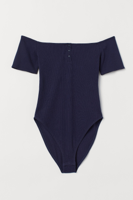


--- SEASON ---
  Summer   : 0.9482  |  ✅ PASS
  Winter   : 0.0056  |  ❌ FAIL
  Spring   : 0.0202  |  ❌ FAIL
  Autumn   : 0.0259  |  ❌ FAIL

--- OCCASION ---
  Casual   : 0.7675  |  ✅ PASS
  Formal   : 0.0536  |  ❌ FAIL
  Sport    : 0.1461  |  ❌ FAIL
  Party    : 0.0328  |  ❌ FAIL


🏷️ ID: 0913688002


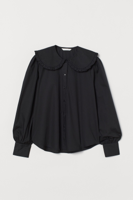


--- SEASON ---
  Summer   : 0.2569  |  ❌ FAIL
  Winter   : 0.4721  |  ✅ PASS
  Spring   : 0.0894  |  ❌ FAIL
  Autumn   : 0.1816  |  ❌ FAIL

--- OCCASION ---
⚠️ AI is Confused (Max score 32.56% < 35%). Forcing Single Label.
  Casual   : 0.2720  |  ❌ FAIL
  Formal   : 0.3048  |  ❌ FAIL
  Sport    : 0.0977  |  ❌ FAIL
  Party    : 0.3256  |  ✅ PASS (Forced Winner)


🏷️ ID: 0380609037


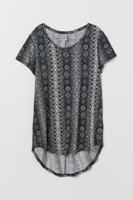


--- SEASON ---
  Summer   : 0.7957  |  ✅ PASS
  Winter   : 0.0200  |  ❌ FAIL
  Spring   : 0.1534  |  ❌ FAIL
  Autumn   : 0.0309  |  ❌ FAIL

--- OCCASION ---
  Casual   : 0.8683  |  ✅ PASS
  Formal   : 0.0145  |  ❌ FAIL
  Sport    : 0.0316  |  ❌ FAIL
  Party    : 0.0856  |  ❌ FAIL


🏷️ ID: 0773766004


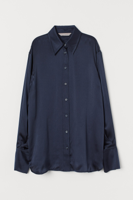


--- SEASON ---
  Summer   : 0.2571  |  ❌ FAIL
  Winter   : 0.5024  |  ✅ PASS
  Spring   : 0.1033  |  ❌ FAIL
  Autumn   : 0.1372  |  ❌ FAIL

--- OCCASION ---
  Casual   : 0.7249  |  ✅ PASS
  Formal   : 0.2181  |  ❌ FAIL
  Sport    : 0.0158  |  ❌ FAIL
  Party    : 0.0412  |  ❌ FAIL


🏷️ ID: 0880741002


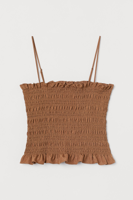


--- SEASON ---
  Summer   : 0.8201  |  ✅ PASS
  Winter   : 0.0156  |  ❌ FAIL
  Spring   : 0.0378  |  ❌ FAIL
  Autumn   : 0.1266  |  ❌ FAIL

--- OCCASION ---
  Casual   : 0.4539  |  ✅ PASS
  Formal   : 0.1245  |  ❌ FAIL
  Sport    : 0.1172  |  ❌ FAIL
  Party    : 0.3044  |  ✅ PASS


🏷️ ID: 0906684002


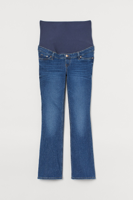


--- SEASON ---
  Summer   : 0.6185  |  ✅ PASS
  Winter   : 0.0273  |  ❌ FAIL
  Spring   : 0.2929  |  ❌ FAIL
  Autumn   : 0.0613  |  ❌ FAIL

--- OCCASION ---
  Casual   : 0.9829  |  ✅ PASS
  Formal   : 0.0027  |  ❌ FAIL
  Sport    : 0.0095  |  ❌ FAIL
  Party    : 0.0049  |  ❌ FAIL


🏷️ ID: 0657850003


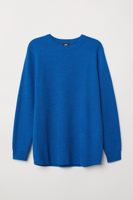


--- SEASON ---
  Summer   : 0.0159  |  ❌ FAIL
  Winter   : 0.8995  |  ✅ PASS
  Spring   : 0.0146  |  ❌ FAIL
  Autumn   : 0.0700  |  ❌ FAIL

--- OCCASION ---
  Casual   : 0.6941  |  ✅ PASS
  Formal   : 0.0595  |  ❌ FAIL
  Sport    : 0.0634  |  ❌ FAIL
  Party    : 0.1830  |  ❌ FAIL


🏷️ ID: 0697058003


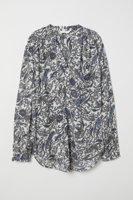


--- SEASON ---
  Summer   : 0.1334  |  ❌ FAIL
  Winter   : 0.1709  |  ❌ FAIL
  Spring   : 0.5696  |  ✅ PASS
  Autumn   : 0.1261  |  ❌ FAIL

--- OCCASION ---
  Casual   : 0.2917  |  ❌ FAIL
  Formal   : 0.1333  |  ❌ FAIL
  Sport    : 0.0318  |  ❌ FAIL
  Party    : 0.5432  |  ✅ PASS


🏷️ ID: 0919980002


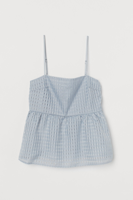


--- SEASON ---
  Summer   : 0.9629  |  ✅ PASS
  Winter   : 0.0052  |  ❌ FAIL
  Spring   : 0.0101  |  ❌ FAIL
  Autumn   : 0.0218  |  ❌ FAIL

--- OCCASION ---
  Casual   : 0.5980  |  ✅ PASS
  Formal   : 0.0464  |  ❌ FAIL
  Sport    : 0.1343  |  ❌ FAIL
  Party    : 0.2213  |  ❌ FAIL


🏷️ ID: 0615176001


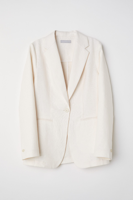


--- SEASON ---
  Summer   : 0.5045  |  ✅ PASS
  Winter   : 0.2036  |  ❌ FAIL
  Spring   : 0.2646  |  ❌ FAIL
  Autumn   : 0.0272  |  ❌ FAIL

--- OCCASION ---
  Casual   : 0.0892  |  ❌ FAIL
  Formal   : 0.8458  |  ✅ PASS
  Sport    : 0.0061  |  ❌ FAIL
  Party    : 0.0589  |  ❌ FAIL



In [20]:
from IPython.display import display, HTML

# 1. Grab 10 random valid items
sample_df = test_df.sample(n=10)
THRESHOLD = 0.20

print("🔍 Running AI X-Ray on 10 Random Items...\n")
print("-" * 50)

for index, row in sample_df.iterrows():
    article_id = str(row['article_id']).split('.')[0].zfill(10)
    subfolder = article_id[:3]
    img_path = os.path.join(DATA_DIR, "images", subfolder, f"{article_id}.jpg")
    
    try:
        # Open and resize image to keep the notebook clean
        image = Image.open(img_path).convert("RGB")
        display_img = image.copy()
        display_img.thumbnail((200, 200)) # Make it small enough to easily scroll
        
        print(f"\n🏷️ ID: {article_id}")
        display(display_img)
        
        # Process Seasons and Occasions
        for category_group, relations in [
            (["Summer", "Winter", "Spring", "Autumn"], "SEASON"),
            (["Casual", "Formal", "Sport", "Party"], "OCCASION")
        ]:
            print(f"\n--- {relations} ---")
            
            # Prepare Prompts
            all_group_prompts = []
            lengths = []
            for label in category_group:
                prompts = ensemble_prompts[label]
                all_group_prompts.extend(prompts)
                lengths.append(len(prompts))
                
            # Run AI
            inputs = processor(text=all_group_prompts, images=image, return_tensors="pt", padding=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
            
            probs = outputs.logits_per_image.softmax(dim=1)[0].cpu().numpy()
            
            # Smart Summing
            label_scores = []
            start_idx = 0
            for length in lengths:
                label_scores.append(probs[start_idx:start_idx+length].sum())
                start_idx += length
                
            # Logic & Thresholding
            max_score = max(label_scores)
            max_index = np.argmax(label_scores)
            is_confused = max_score < 0.35
            
            if is_confused:
                print(f"⚠️ AI is Confused (Max score {max_score:.2%} < 35%). Forcing Single Label.")
            
            # Print Pass/Fail for each label
            for i, score in enumerate(label_scores):
                status = "❌ FAIL"
                
                if is_confused:
                    if i == max_index:
                        status = "✅ PASS (Forced Winner)"
                else:
                    if score >= THRESHOLD and (max_score - score) <= 0.15:
                        status = "✅ PASS"
                
                # Format the text to align nicely
                label_name = category_group[i].ljust(8)
                print(f"  {label_name} : {score:.4f}  |  {status}")
                
        print("\n" + "=" * 50)
        
    except Exception as e:
        print(f"🚨 Missing Image or Error for {article_id}: {e}")

Count the item based on by categories for women and men garment

In [21]:
# ── 1. Category counts ──────────────────────────────────────────────────────
category_counts = (
    results_df[results_df['relation'] == 'in_category']['tail']
    .value_counts()
    .reset_index()
)
category_counts.columns = ['Category', 'Count']
print("=== Category Counts ===")
print(category_counts)

# ── 2. Season counts per category ───────────────────────────────────────────
# Get each head's category
head_category = results_df[results_df['relation'] == 'in_category'][['head', 'tail']].rename(columns={'tail': 'category'})

# Get each head's season
head_season = results_df[results_df['relation'] == 'has_season'][['head', 'tail']].rename(columns={'tail': 'season'})

# Get each head's occasion
head_occasion = results_df[results_df['relation'] == 'has_occasion'][['head', 'tail']].rename(columns={'tail': 'occasion'})

# Merge category + season
cat_season = head_category.merge(head_season, on='head', how='left')

# Merge category + occasion
cat_occasion = head_category.merge(head_occasion, on='head', how='left')

# ── 3. Season breakdown per category ────────────────────────────────────────
season_counts = (
    cat_season.groupby(['category', 'season'])
    .size()
    .reset_index(name='count')
    .sort_values(['category', 'count'], ascending=[True, False])
)
print("\n=== Season Counts per Category ===")
print(season_counts)

# ── 4. Occasion breakdown per category ──────────────────────────────────────
occasion_counts = (
    cat_occasion.groupby(['category', 'occasion'])
    .size()
    .reset_index(name='count')
    .sort_values(['category', 'count'], ascending=[True, False])
)
print("\n=== Occasion Counts per Category ===")
print(occasion_counts)

=== Category Counts ===
Empty DataFrame
Columns: [Category, Count]
Index: []

=== Season Counts per Category ===
Empty DataFrame
Columns: [category, season, count]
Index: []

=== Occasion Counts per Category ===
Empty DataFrame
Columns: [category, occasion, count]
Index: []


# Evaluation Metrics based on manual labeled data

In [22]:
ground_truth = {
    # SEASONS
    # Summer
    "0108775015": "Summer", 
    "0554598010": "Summer",
    "0630084003": "Summer",
    "0696542001": "Summer",
    "0832453007": "Summer",
    "0604049007": "Summer",
    "0634665001": "Summer",
    "0776746006": "Summer",
    "0630323032": "Summer",
    "0892857003": "Summer",
    # Winter
    "0761335002": "Winter",
    "0714321001": "Winter",
    "0760466004": "Winter",
    "0634727002": "Winter",
    "0838485001": "Winter",
    "0720120001": "Winter",
    "0798516001": "Winter",
    "0651110001": "Winter",
    "0873276004": "Winter",
    "0820431001": "Winter",

    # Spring
    "0681385001": "Spring",
    "0797835006": "Spring",
    "0708490006": "Spring",
    "0695263003": "Spring",
    "0915611004": "Spring",
    "0723167003": "Spring",
    "0756730001": "Spring",
    "0588213001": "Spring",
    "0750712004": "Spring",
    "0605710004": "Spring",

    # Autumn
    "0664319014": "Autumn",
    "0542473002": "Autumn",
    "0868874002": "Autumn",
    "0926105003": "Autumn",
    "0697649004": "Autumn",
    "0677930002": "Autumn",
    "0682952003": "Autumn",
    "0794215002": "Autumn",
    "0708471005": "Autumn",
    "0617426005": "Autumn",
    
    # OCCASIONS
    # Formal
    "0123456780": "Formal",
    "0652731006": "Formal",
    "0718549001": "Formal",
    "0552473001": "Formal",
    "0700375001": "Formal",
    "0762169007": "Formal",
    "0501616048": "Formal",
    "0752814003": "Formal",
    "0872075001": "Formal",
    "0695632100": "Formal",
    # Sport
    "0987654321": "Sport",
    "0708489001": "Sport",
    "0881709001": "Sport",
    "0631837004": "Sport",
    "0700950001": "Sport",
    "0598785003": "Sport",
    "0590373001": "Sport",
    "0738713030": "Sport",
    "0743562002": "Sport",
    "0864953001": "Sport",
    # Party
    "0851496001": "Party",
    "0770916002": "Party",
    "0913033002": "Party",
    "0712228002": "Party",
    "0594941001": "Party",
    "0736678004": "Party",
    "0881361004": "Party",
    "0714505001": "Party",
    "0737328001": "Party",
    "0870375001": "Party",
    # Casual
    "0613465004": "Casual",
    "0574051002": "Casual",
    "0659379003": "Casual",
    "0683864010": "Casual",
    "0607310001": "Casual",
    "0732017013": "Casual",
    "0843685005": "Casual",
    "0554758002": "Casual",
    "0634541003": "Casual",
    "0611732002": "Casual"
}

In [23]:
import pandas as pd
from sklearn.metrics import classification_report
from pathlib import Path

# 1. Golden Dataset
ground_truth = {
    # SEASONS
    "0108775015": "Summer", "0554598010": "Summer", "0630084003": "Summer", "0696542001": "Summer", "0832453007": "Summer", "0604049007": "Summer", "0634665001": "Summer", "0776746006": "Summer", "0630323032": "Summer", "0892857003": "Summer",
    "0761335002": "Winter", "0714321001": "Winter", "0760466004": "Winter", "0634727002": "Winter", "0838485001": "Winter", "0720120001": "Winter", "0798516001": "Winter", "0651110001": "Winter", "0873276004": "Winter", "0820431001": "Winter",
    "0681385001": "Spring", "0797835006": "Spring", "0708490006": "Spring", "0695263003": "Spring", "0915611004": "Spring", "0723167003": "Spring", "0756730001": "Spring", "0588213001": "Spring", "0750712004": "Spring", "0605710004": "Spring",
    "0664319014": "Autumn", "0542473002": "Autumn", "0868874002": "Autumn", "0926105003": "Autumn", "0697649004": "Autumn", "0677930002": "Autumn", "0682952003": "Autumn", "0794215002": "Autumn", "0708471005": "Autumn", "0617426005": "Autumn",
    
    # OCCASIONS
    "0123456780": "Formal", "0652731006": "Formal", "0718549001": "Formal", "0552473001": "Formal", "0700375001": "Formal", "0762169007": "Formal", "0501616048": "Formal", "0752814003": "Formal", "0872075001": "Formal", "0695632100": "Formal",
    "0987654321": "Sport", "0708489001": "Sport", "0881709001": "Sport", "0631837004": "Sport", "0700950001": "Sport", "0598785003": "Sport", "0590373001": "Sport", "0738713030": "Sport", "0743562002": "Sport", "0864953001": "Sport",
    "0851496001": "Party", "0770916002": "Party", "0913033002": "Party", "0712228002": "Party", "0594941001": "Party", "0736678004": "Party", "0881361004": "Party", "0714505001": "Party", "0737328001": "Party", "0870375001": "Party",
    "0613465004": "Casual", "0574051002": "Casual", "0659379003": "Casual", "0683864010": "Casual", "0607310001": "Casual", "0732017013": "Casual", "0843685005": "Casual", "0554758002": "Casual", "0634541003": "Casual", "0611732002": "Casual"
}

# 2. Load the Knowledge Graph
kg_df = pd.read_csv(project_root / "data" / "processed"/"final_knowledge_graph.csv")
kg_df['head'] = kg_df['head'].astype(str).str.zfill(10)

# 3. Setup lists to hold the comparisons
y_true_season, y_pred_season = [], []
y_true_occasion, y_pred_occasion = [], []

# 4. Run the Evaluation Loop
for article_id, true_label in ground_truth.items():
    
    # Get all graph edges for this specific item
    item_edges = kg_df[kg_df['head'] == article_id]
    
    # -- EVALUATE SEASONS --
    if true_label in ["Summer", "Winter", "Spring", "Autumn"]:
        y_true_season.append(true_label)
        
        # Get what the AI predicted
        predicted_seasons = item_edges[item_edges['relation'] == 'has_season']['tail'].tolist()
        
        if true_label in predicted_seasons:
            y_pred_season.append(true_label) # The AI got it right!
        elif len(predicted_seasons) > 0:
            y_pred_season.append(predicted_seasons[0]) # The AI guessed wrong
        else:
            y_pred_season.append("Unlabeled") # The AI completely missed it

    # -- EVALUATE OCCASIONS --
    elif true_label in ["Formal", "Sport", "Party", "Casual"]:
        y_true_occasion.append(true_label)
        
        predicted_occasions = item_edges[item_edges['relation'] == 'has_occasion']['tail'].tolist()
        
        if true_label in predicted_occasions:
            y_pred_occasion.append(true_label)
        elif len(predicted_occasions) > 0:
            y_pred_occasion.append(predicted_occasions[0])
        else:
            y_pred_occasion.append("Unlabeled")

# 5. Print the Final Report
# Define exactly what words to grade (Unlabeled is NOT in these lists)
season_labels = ["Summer", "Winter", "Spring", "Autumn"]
occasion_labels = ["Formal", "Sport", "Party", "Casual"]

print("=" * 50)
print(" SEASON EXTRACTION PERFORMANCE ")
print("=" * 50)
print(classification_report(y_true_season, y_pred_season, labels=season_labels, zero_division=0))

print("\n" + "=" * 50)
print(" OCCASION EXTRACTION PERFORMANCE ")
print("=" * 50)
print(classification_report(y_true_occasion, y_pred_occasion, labels=occasion_labels, zero_division=0))

 SEASON EXTRACTION PERFORMANCE 
              precision    recall  f1-score   support

      Summer       1.00      1.00      1.00        10
      Winter       1.00      1.00      1.00        10
      Spring       1.00      0.90      0.95        10
      Autumn       1.00      0.80      0.89        10

   micro avg       1.00      0.93      0.96        40
   macro avg       1.00      0.93      0.96        40
weighted avg       1.00      0.93      0.96        40


 OCCASION EXTRACTION PERFORMANCE 
              precision    recall  f1-score   support

      Formal       1.00      0.70      0.82        10
       Sport       1.00      0.90      0.95        10
       Party       1.00      1.00      1.00        10
      Casual       0.82      0.90      0.86        10

   micro avg       0.95      0.88      0.91        40
   macro avg       0.95      0.88      0.91        40
weighted avg       0.95      0.88      0.91        40



Print Text Report and Export Charts

 ☀️❄️ SEASON EXTRACTION PERFORMANCE 🌸🍂 
              precision    recall  f1-score   support

      Summer       1.00      1.00      1.00        10
      Winter       1.00      1.00      1.00        10
      Spring       1.00      0.90      0.95        10
      Autumn       1.00      0.80      0.89        10

   micro avg       1.00      0.93      0.96        40
   macro avg       1.00      0.93      0.96        40
weighted avg       1.00      0.93      0.96        40


 🥂👔 OCCASION EXTRACTION PERFORMANCE 👟👕 
              precision    recall  f1-score   support

      Formal       1.00      0.70      0.82        10
       Sport       1.00      0.90      0.95        10
       Party       1.00      1.00      1.00        10
      Casual       0.82      0.90      0.86        10

   micro avg       0.95      0.88      0.91        40
   macro avg       0.95      0.88      0.91        40
weighted avg       0.95      0.88      0.91        40


Generating visual charts...
✅ Saved chart to: /U

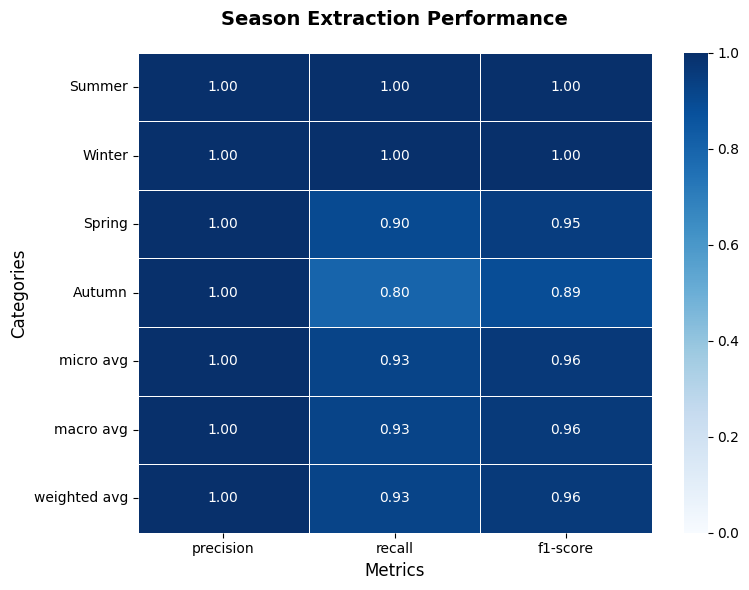

✅ Saved chart to: /Users/yongchenhow/Local Data/Nus/Class/Intelligent Reasoning System/Practice Module/Project/fashion-recommender/SystemCode/data/processed/occasion_evaluation_chart.png


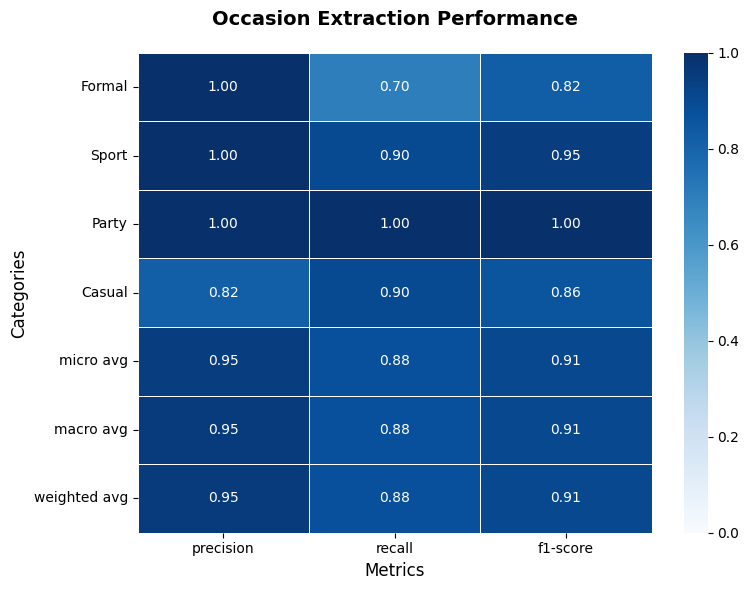

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 5. Print Text Reports AND Export Charts

# Define exactly what words to grade
season_labels = ["Summer", "Winter", "Spring", "Autumn"]
occasion_labels = ["Formal", "Sport", "Party", "Casual"]

# --- PART A: Print the Text Results ---
print("=" * 50)
print(" ☀️❄️ SEASON EXTRACTION PERFORMANCE 🌸🍂 ")
print("=" * 50)
print(classification_report(y_true_season, y_pred_season, labels=season_labels, zero_division=0))

print("\n" + "=" * 50)
print(" 🥂👔 OCCASION EXTRACTION PERFORMANCE 👟👕 ")
print("=" * 50)
print(classification_report(y_true_occasion, y_pred_occasion, labels=occasion_labels, zero_division=0))


# --- PART B: Generate and Save the Charts ---
print("\nGenerating visual charts...")

# 1. Define your output directory and make sure it exists!
OUTPUT_DIR = project_root / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # Safety check

# Get the reports as dictionaries for the graphing tool
season_report_dict = classification_report(y_true_season, y_pred_season, labels=season_labels, zero_division=0, output_dict=True)
occasion_report_dict = classification_report(y_true_occasion, y_pred_occasion, labels=occasion_labels, zero_division=0, output_dict=True)

def plot_classification_report(report_dict, title, filepath):
    df = pd.DataFrame(report_dict).iloc[:-1, :].T
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(df, annot=True, cmap="Blues", fmt=".2f", vmin=0, vmax=1, linewidths=.5)
    
    plt.title(title, pad=20, fontsize=14, fontweight='bold')
    plt.ylabel('Categories', fontsize=12)
    plt.xlabel('Metrics', fontsize=12)
    plt.tight_layout()
    
    # Save the chart using the full filepath
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    
    # Because 'filepath' is a Path object, we can print its exact location nicely
    print(f"✅ Saved chart to: {filepath.absolute()}") 
    
    plt.show()

# 2. Combine the OUTPUT_DIR with the filenames using the '/' operator
season_file = OUTPUT_DIR / "season_evaluation_chart.png"
occasion_file = OUTPUT_DIR / "occasion_evaluation_chart.png"

# Run the graphing function
plot_classification_report(season_report_dict, "Season Extraction Performance", season_file)
plot_classification_report(occasion_report_dict, "Occasion Extraction Performance", occasion_file)

-------------------------------------------------------------------------------------------------------

# Export the final complete kg

In [25]:
# Filter the DataFrame

# Category
df_category = pd.DataFrame({
    'head' : category_triplets['head'],
    'relation' : category_triplets['relation'],
    'tail' : category_triplets['tail'],
    'weight' : np.nan,
    'tail_color' : np.nan
})

# Color
df_color = pd.DataFrame({
    'head' : valid_items['article_id'],
    'relation' : 'has_color',
    'tail' : valid_items['colour_group_name'],
    'weight' : np.nan,
    'tail_color' : np.nan,
})

# Pattern
df_pattern = pd.DataFrame({
    'head' : valid_items['article_id'],
    'relation' : 'has_pattern',
    'tail' : valid_items['graphical_appearance_name'],
    'weight' : np.nan,
    'tail_color' : np.nan,
})

# Best Matches
df_matches = pd.DataFrame({
    'head' : match_edges['source'],
    'relation' : match_edges['relation'],
    'tail' : match_edges['target'],
    'weight' : match_edges['weight'],  # Using Lift as the weight
    'tail_color' : match_edges['target'].map(valid_items.set_index('article_id')['colour_group_name'])
})

# Price
df_price = pd.DataFrame({
    'head' : valid_items['article_id'],
    'relation' : 'has_price',
    'tail' : valid_items['price_sgd'],  # Using the scaled price in
    'weight' : np.nan,
    'tail_color' : np.nan
})

# Dead Stock
stock_status_labels = np.where(valid_items['dead_stock'], 'Dead Stock', 'Active Stock')
df_deadstock = pd.DataFrame({
    'head' : valid_items['article_id'],
    'relation' : 'has_stock_status',
    'tail' : stock_status_labels,
    'weight' : np.nan,
    'tail_color' : np.nan
})



# Concatenate all edges into one DataFrame
final_edges = pd.concat([df_category, df_color, df_pattern, df_matches, df_price, results_df, df_deadstock], ignore_index=True)

# Clean up the DataFrame (e.g., drop rows with missing heads or tails)
final_edges = final_edges.dropna(subset=['head', 'tail']).reset_index(drop=True)
final_edges['head'] = final_edges['head'].astype(str).str.zfill(10)
final_edges = final_edges.sort_values(by=['head',], ascending=[True])
display(final_edges.head(10))


,head,relation,tail,weight,tail_color
0,0108775015,in_category,Ladieswear Top,<NA>,NaN
71308,0108775015,has_pattern,Solid,<NA>,NaN
342836,0108775015,has_stock_status,Active Stock,<NA>,NaN
106962,0108775015,best_matches_with,0573552001,79.221555,Black
106963,0108775015,best_matches_with,0513402001,36.970059,Dark Blue
106964,0108775015,best_matches_with,0613967003,20.538922,Dark Grey
106965,0108775015,best_matches_with,0708303002,17.329715,Black
106966,0108775015,best_matches_with,0532537001,12.323353,Grey
225668,0108775015,has_price,9.77,<NA>,NaN
261322,0108775015,has_season,Summer,0.9985,NaN


# -----------------------------------------------------------------------

In [27]:
# Export to CSV
OUTPUT_DIR = project_root / "data" / "processed"
# Export the dataframe to a CSV file in your current directory
final_edges.to_csv(OUTPUT_DIR / "final_knowledge_graph.csv", index=False)

print("✅ CSV successfully exported!")

✅ CSV successfully exported!
